In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

from scipy.stats import spearmanr

# Code for Metric Score Calculations

In [2]:
def full_cw_sil_score(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    #pairwise distance matrix
    D = cdist(X, X)

    # computation of centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # to avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # to exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist * inter_weights) / np.sum(inter_weights)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [3]:
def cw_sil_score(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    # pairwise distance matrix
    D = cdist(X, X)

    # centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            #inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist) / len(inter_dist)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [4]:
def dunn_index(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    # Compute pairwise distances
    D = cdist(X, X)

    # Intra-cluster diameter (max distance inside cluster)
    intra_dists = []
    for l in unique_labels:
        cluster_points = np.where(labels == l)[0]
        if len(cluster_points) < 2:
            continue
        cluster_D = D[np.ix_(cluster_points, cluster_points)]
        intra_dists.append(np.max(cluster_D))

    if len(intra_dists) == 0:
        return 0

    max_intra = np.max(intra_dists)

    # Inter-cluster distance (min distance between clusters)
    inter_dists = []
    for i, li in enumerate(unique_labels):
        for lj in unique_labels[i+1:]:
            cluster_i = np.where(labels == li)[0]
            cluster_j = np.where(labels == lj)[0]
            inter_cluster_D = D[np.ix_(cluster_i, cluster_j)]
            inter_dists.append(np.min(inter_cluster_D))

    min_inter = np.min(inter_dists)

    return min_inter / max_intra

In [5]:
# from https://github.com/nobertomaciel/sklearn/blob/main/xie_beni.py

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import pairwise_distances
from sklearn.utils.validation import check_X_y
from sklearn.utils import _safe_indexing


# Author: Noberto Maciel <nobertomaciel@hotmail.com>
# License: BSD 3 clause

def xie_beni_index(X, labels):
    """Compute the Xie Beni Index.

    Xie and Beni introduced Xie-Beni (XB) index method in 1991. 
    XB index is focus on separation and compactness. 
    Separation is a measure of the distance between one cluster and 
    another cluster and compactness is a measure of proximity between data 
    points in a cluster (Lathief 2020).

    The minimum score is zero, with lower values indicating better clustering.

    Read more in the :ref:`User Guide <xie-beni_index>`.

    .. versionadded:: 0.10

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        A list of ``n_features``-dimensional data points. Each row corresponds
        to a single data point.

    labels : array-like of shape (n_samples,)
        Predicted labels for each sample.

    Returns
    -------
    score: float
        The resulting Xie Beni Index.

    References
    ----------
    .. [1] XIE, Xuanli Lisa ; BENI, Gerardo. 
        A validity measure for fuzzy clustering. 
        IEEE Transactions on Pattern Analysis & Machine Intelligence, 
        v. 13, n. 08, p. 841-847, 1991.
       [2] LATHIEF, Muttabik Fathul; SOESANTI, Indah; PERMANASARI, Adhistya Erna. 
        Combination of Fuzzy C-Means, Xie-Beni Index, and Backpropagation Neural Network for Better Forecasting Result. 
        Science and Technology Publications: Setubal, Portugal, 
        p. 72-77, 2020.
    """
    def check_number_of_labels(n_labels, n_samples):
        """Check that number of labels are valid.

        Parameters
        ----------
        n_labels : int
            Number of labels.

        n_samples : int
            Number of samples.
        """
        if not 1 < n_labels < n_samples:
            raise ValueError(
                "Number of labels is %d. Valid values are 2 to n_samples - 1 (inclusive)"
                % n_labels
            )
    X, labels = check_X_y(X, labels)
    le = LabelEncoder()
    labels = le.fit_transform(labels)
    n_samples, _ = X.shape
    n_labels = len(le.classes_)
    check_number_of_labels(n_labels, n_samples)

    intra_dists = np.zeros(n_labels) # same cluster dist
    centroids = np.zeros((n_labels, len(X[0])), dtype=float)
    for k in range(n_labels):
        cluster_k = _safe_indexing(X, labels == k)
        centroid = cluster_k.mean(axis=0)
        centroids[k] = centroid
        intra_dists[k] = np.sum((pairwise_distances(cluster_k, [centroid])**2))

    centroid_distances = pairwise_distances(centroids)

    if np.allclose(intra_dists, 0) or np.allclose(centroid_distances, 0):
        return 0.0

    centroid_distances[centroid_distances == 0] = np.inf

    scores = (np.sum(intra_dists))/(n_labels*(np.min((centroid_distances**2))))
    return scores

In [6]:
# from https://github.com/Simon-Bertrand/Clusters-Features/blob/main/ClustersFeatures/src/_score_index.py
# chatgpt's function version from the class version in this github repo

def pbm_index(X, labels):
    X, labels = check_X_y(X, labels)
    labels = LabelEncoder().fit_transform(labels)

    n_clusters = len(np.unique(labels))
    if n_clusters < 2:
        raise ValueError("PBM index requires at least 2 clusters")

    # Global barycenter
    global_center = X.mean(axis=0)

    # ET: total scatter
    ET = np.linalg.norm(X - global_center, axis=1).sum()

    # Cluster centroids and EW
    centroids = []
    EW = 0.0
    for k in range(n_clusters):
        cluster_k = X[labels == k]
        centroid = cluster_k.mean(axis=0)
        centroids.append(centroid)
        EW += np.linalg.norm(cluster_k - centroid, axis=1).sum()

    centroids = np.array(centroids)

    # Max inter-centroid distance
    Dmax = pairwise_distances(centroids).max()

    pbm = ((ET * Dmax) / (EW * n_clusters)) ** 2
    return pbm

In [7]:
def evaluate_all(X, true_labels, pred_labels, include_ext=False):
    scores = {
        "Standard-Silhouette": silhouette_score(X, pred_labels),
        "Full-CW-Silhouette": full_cw_sil_score(X, pred_labels),
        "CW-Silhouette": cw_sil_score(X, pred_labels),
        "DBI": davies_bouldin_score(X, pred_labels),
        "CHI": calinski_harabasz_score(X, pred_labels),
        "Dunn": dunn_index(X, pred_labels),
        "XBI": xie_beni_index(X, pred_labels),
        "PBM": pbm_index(X, pred_labels),
    }

    if include_ext:
        scores["ARI"] = adjusted_rand_score(true_labels, pred_labels)
        scores["NMI"] = normalized_mutual_info_score(true_labels, pred_labels)

    return scores

# Metric Score Calculation Using True Labels

In [8]:
rng = np.random.default_rng(51)

centroids = np.array([
    [5.0, 3.0],
    [7.0, 7.0],
    [3.0, 7.0]
])

n_samples_per_cluster = 67
std_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

runs = 10 

In [9]:
results = []

for std in std_values:
    for run in range(runs):

        X = np.vstack([
            rng.normal(loc=center, scale=std,
                             size=(n_samples_per_cluster, 2))
            for center in centroids
        ])

        labels = np.repeat([0, 1, 2], n_samples_per_cluster)

        scores = evaluate_all(X, true_labels=labels, pred_labels=labels)
        
        results.append([std, run, scores["Standard-Silhouette"], 
                        scores["Full-CW-Silhouette"], scores["CW-Silhouette"], 
                        scores["DBI"], scores["CHI"], scores["Dunn"],
                        scores["XBI"], scores["PBM"]])

In [10]:
df_results = pd.DataFrame(results, columns=["std", "run", "Standard-Silhouette", "Full-CW-Silhouette", "CW-Silhouette", "DBI", "CHI", "Dunn", "XBI", "PBM"])
display(df_results)


,std,run,Standard-Silhouette,Full-CW-Silhouette,CW-Silhouette,DBI,CHI,Dunn,XBI,PBM
0,0.2,0,0.909272,0.922849,0.922823,0.124505,6928.136128,2.331407,0.363569,201.163941
1,0.2,1,0.912503,0.925716,0.925783,0.124439,7484.290800,2.460441,0.346722,227.018381
2,0.2,2,0.915860,0.927456,0.927632,0.117077,8186.104130,2.868783,0.314149,233.125179
3,0.2,3,0.916480,0.929997,0.930175,0.115695,8208.971415,2.446848,0.311314,239.129480
4,0.2,4,0.911308,0.922689,0.922751,0.122977,7340.789579,2.172608,0.352240,219.946675
...,...,...,...,...,...,...,...,...,...,...
75,2.0,5,0.209656,0.255037,0.319305,1.186313,80.315106,0.000539,31.466248,4.377081
76,2.0,6,0.218918,0.265382,0.316597,1.212064,84.790110,0.006243,34.275419,5.104346
77,2.0,7,0.151987,0.192545,0.265388,1.482524,62.798870,0.007243,54.152215,3.582049
78,2.0,8,0.178268,0.218551,0.285505,1.272973,67.098604,0.005058,34.588976,3.106402


In [11]:
grouped = df_results.groupby("std").mean().reset_index()
grouped = grouped.drop("run", axis=1)
display(grouped)

,std,Standard-Silhouette,Full-CW-Silhouette,CW-Silhouette,DBI,CHI,Dunn,XBI,PBM
0,0.2,0.914778,0.926768,0.926827,0.119016,8000.110441,2.556981,0.323485,231.979223
1,0.4,0.826595,0.850004,0.850292,0.240089,1976.206517,0.900573,1.312861,59.534480
2,0.6,0.727720,0.762040,0.763542,0.368192,834.824553,0.314910,3.072966,25.679749
3,0.8,0.639800,0.682531,0.686391,0.484819,490.852399,0.127273,5.170879,15.299741
4,1.0,0.547511,0.597073,0.605857,0.599839,323.176548,0.022040,8.157929,11.152085
5,1.2,0.461738,0.517020,0.532256,0.721291,223.639991,0.016179,11.651996,8.238293
6,1.5,0.342152,0.397400,0.427302,0.908533,140.617991,0.007418,18.418541,5.972501
7,2.0,0.191910,0.234056,0.295915,1.277504,75.321118,0.005343,37.459722,4.184380


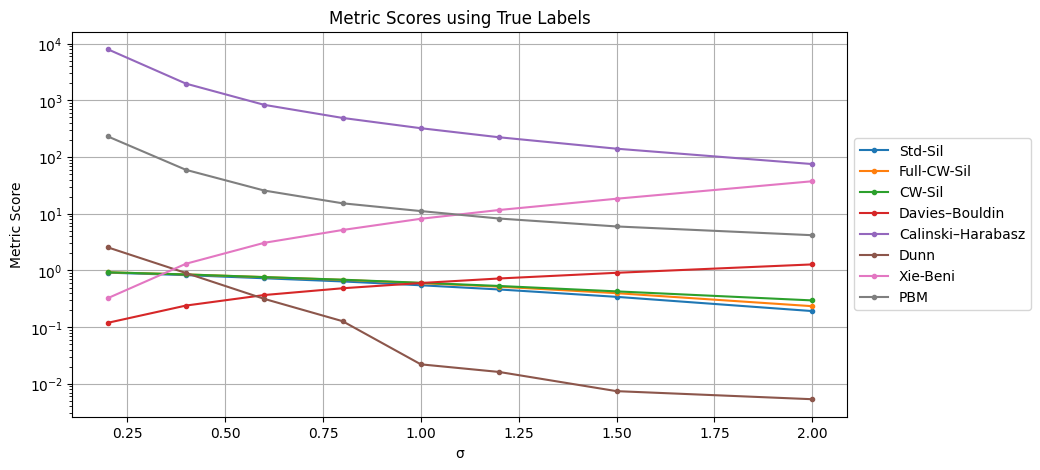

In [12]:
plt.figure(figsize=(10,5))
plt.plot(grouped["std"], grouped["Standard-Silhouette"], label="Std-Sil", marker=".")
plt.plot(grouped["std"], grouped["Full-CW-Silhouette"], label="Full-CW-Sil", marker=".")
plt.plot(grouped["std"], grouped["CW-Silhouette"], label="CW-Sil", marker=".")
plt.plot(grouped["std"], grouped["DBI"], label="Davies–Bouldin", marker=".")
plt.plot(grouped["std"], grouped["CHI"], label="Calinski–Harabasz", marker=".")
plt.plot(grouped["std"], grouped["Dunn"], label="Dunn", marker=".")
plt.plot(grouped["std"], grouped["XBI"], label="Xie-Beni", marker=".")
plt.plot(grouped["std"], grouped["PBM"], label="PBM", marker=".")

plt.axhline(0, linestyle="--")
plt.xlabel("σ")
plt.ylabel("Metric Score")
plt.title("Metric Scores using True Labels")
plt.yscale("log")
# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()

plt.show()

# Metric Score Calculation Using Predicted Labels from K-Means

In [13]:
k_values = [i for i in range(2,9)]

In [14]:
results = []
results_scores_k3 = []
results_corr_ari = []
results_corr_nmi = []


for std in std_values:
    for run in range(runs):

        X = np.vstack([
            rng.normal(loc=center, scale=std,
                             size=(n_samples_per_cluster, 2))
            for center in centroids
        ])

        true_labels = np.repeat([0, 1, 2], n_samples_per_cluster)

        scores_std = []
        scores_fullcw = []
        scores_cw = []
        scores_dbi = []
        scores_chi = []
        scores_dun = []
        scores_xbi = []
        scores_pbm = []
        scores_ari = []
        scores_nmi = []

        for k in k_values:
            model = KMeans(n_clusters=k, random_state=51, n_init=10)
            pred_labels = model.fit_predict(X)

            scores_std.append(silhouette_score(X, pred_labels))
            scores_fullcw.append(full_cw_sil_score (X, pred_labels))
            scores_cw.append(cw_sil_score (X, pred_labels))
            scores_dbi.append(davies_bouldin_score(X, pred_labels))
            scores_chi.append(calinski_harabasz_score (X, pred_labels))
            scores_dun.append(dunn_index(X, pred_labels))
            scores_xbi.append(xie_beni_index(X, pred_labels))
            scores_pbm.append(pbm_index(X, pred_labels))
            scores_ari.append(adjusted_rand_score (true_labels, pred_labels))
            scores_nmi.append(normalized_mutual_info_score(true_labels, pred_labels))

        scores_std = np.array(scores_std)
        scores_fullcw = np.array(scores_fullcw)
        scores_cw = np.array(scores_cw)
        scores_dbi = np.array(scores_dbi)
        scores_chi = np.array(scores_chi)
        scores_dun = np.array(scores_dun)
        scores_xbi = np.array(scores_xbi)
        scores_pbm = np.array(scores_pbm)
        scores_ari = np.array(scores_ari)
        scores_nmi = np.array(scores_nmi)

        best_std_k = k_values[np.argmax(scores_std)]
        best_fullcw_k = k_values[np.argmax(scores_fullcw)]
        best_cw_k = k_values[np.argmax(scores_cw)]
        best_dbi_k = k_values[np.argmin(scores_dbi)]
        best_chi_k = k_values[np.argmax(scores_chi)]
        best_dun_k = k_values[np.argmax(scores_dun)]
        best_xbi_k = k_values[np.argmin(scores_xbi)]
        best_pbm_k = k_values[np.argmax(scores_pbm)]
        best_ari_k = k_values[np.argmax(scores_ari)]
        best_nmi_k = k_values[np.argmax(scores_nmi)]

        scores_dbi = -scores_dbi
        scores_xbi = -scores_xbi

        corr_std_ari, p_std_ari = spearmanr(scores_std, scores_ari)
        corr_fullcw_ari, p_fullcw_ari = spearmanr(scores_fullcw, scores_ari)
        corr_cw_ari, p_cw_ari = spearmanr(scores_cw, scores_ari)
        corr_dbi_ari, p_dbi_ari = spearmanr(scores_dbi, scores_ari)
        corr_chi_ari, p_chi_ari = spearmanr(scores_chi, scores_ari)
        corr_dun_ari, p_dun_ari = spearmanr(scores_dun, scores_ari)
        corr_xbi_ari, p_xbi_ari = spearmanr(scores_xbi, scores_ari)
        corr_pbm_ari, p_pbm_ari = spearmanr(scores_pbm, scores_ari)

        corr_std_nmi, p_std_nmi = spearmanr(scores_std, scores_nmi)
        corr_fullcw_nmi, p_fullcw_nmi = spearmanr(scores_fullcw, scores_nmi)
        corr_cw_nmi, p_cw_nmi = spearmanr(scores_cw, scores_nmi)
        corr_dbi_nmi, p_dbi_nmi = spearmanr(scores_dbi, scores_nmi)
        corr_chi_nmi, p_chi_nmi = spearmanr(scores_chi, scores_nmi)
        corr_dun_nmi, p_dun_nmi = spearmanr(scores_dun, scores_nmi)
        corr_xbi_nmi, p_xbi_nmi = spearmanr(scores_xbi, scores_nmi)
        corr_pbm_nmi, p_pbm_nmi = spearmanr(scores_pbm, scores_nmi)

        scores_dbi = -scores_dbi
        scores_xbi = -scores_xbi
        
        results_scores_k3.append([std, run, scores_std[1], scores_fullcw[1], scores_cw[1], scores_dbi[1], scores_chi[1], scores_dun[1], scores_xbi[1], scores_pbm[1]])
        results.append([std, run, best_std_k, best_fullcw_k, best_cw_k, best_dbi_k, best_chi_k, best_dun_k, best_xbi_k, best_pbm_k, best_ari_k, best_nmi_k])
        results_corr_ari.append([std, run, (corr_std_ari), p_std_ari, (corr_fullcw_ari), p_fullcw_ari, (corr_cw_ari), p_cw_ari, (corr_dbi_ari), p_dbi_ari, (corr_chi_ari), p_chi_ari, (corr_dun_ari), p_dun_ari, (corr_xbi_ari), p_xbi_ari, (corr_pbm_ari), p_pbm_ari])
        results_corr_nmi.append([std, run, (corr_std_nmi), p_std_nmi, (corr_fullcw_nmi), p_fullcw_nmi, (corr_cw_nmi), p_cw_nmi, (corr_dbi_nmi), p_dbi_nmi, (corr_chi_nmi), p_chi_nmi, (corr_dun_nmi), p_dun_nmi, (corr_xbi_nmi), p_xbi_nmi, (corr_pbm_nmi), p_pbm_nmi])


In [15]:
df_results_k3 = pd.DataFrame(results_scores_k3, columns=["std", "run", "Standard-Silhouette", "Full-CW-Silhouette", "CW-Silhouette", "DBI", "CHI", "Dunn", "XBI", "PBM"])
display(df_results_k3)

,std,run,Standard-Silhouette,Full-CW-Silhouette,CW-Silhouette,DBI,CHI,Dunn,XBI,PBM
0,0.2,0,0.915917,0.925727,0.925811,0.118604,8134.940887,2.658966,0.310985,226.299024
1,0.2,1,0.916080,0.926086,0.926171,0.118634,8197.686271,2.411964,0.314342,237.296763
2,0.2,2,0.918322,0.929360,0.929360,0.114324,8574.599083,2.666718,0.298965,251.624530
3,0.2,3,0.913153,0.925975,0.926024,0.122368,7658.932398,2.355337,0.341253,231.094893
4,0.2,4,0.909559,0.923018,0.922946,0.126725,7156.541830,2.345127,0.358346,204.561309
...,...,...,...,...,...,...,...,...,...,...
75,2.0,5,0.355191,0.395980,0.434153,0.923928,134.595065,0.033019,18.571738,6.258157
76,2.0,6,0.382956,0.438306,0.466309,0.858258,157.419980,0.027816,14.314022,7.766444
77,2.0,7,0.403717,0.448330,0.477933,0.867302,161.902667,0.032191,14.384574,9.256916
78,2.0,8,0.377945,0.415086,0.441013,0.856365,155.425558,0.040067,15.611396,7.064401


In [16]:
grouped_k3 = df_results_k3.groupby("std").mean().reset_index()
grouped_k3 = grouped_k3.drop("run", axis=1)
display(grouped_k3)

,std,Standard-Silhouette,Full-CW-Silhouette,CW-Silhouette,DBI,CHI,Dunn,XBI,PBM
0,0.2,0.914359,0.926114,0.926138,0.120116,7892.695753,2.588447,0.327000,229.066574
1,0.4,0.831714,0.853778,0.854222,0.233597,2087.509636,0.991342,1.238271,62.308023
2,0.6,0.736440,0.773434,0.774738,0.358283,881.325660,0.344535,2.939695,28.294474
3,0.8,0.635936,0.676442,0.680614,0.491995,494.906616,0.134889,5.537143,15.894685
4,1.0,0.569439,0.619845,0.627362,0.578674,350.692590,0.064330,7.557367,12.458708
5,1.2,0.497483,0.551105,0.564832,0.675368,253.775892,0.051642,10.079952,9.553268
6,1.5,0.437588,0.488748,0.509840,0.770691,193.987577,0.029404,12.996867,8.160819
7,2.0,0.376343,0.420891,0.452156,0.869938,149.464964,0.031546,15.772125,7.994211


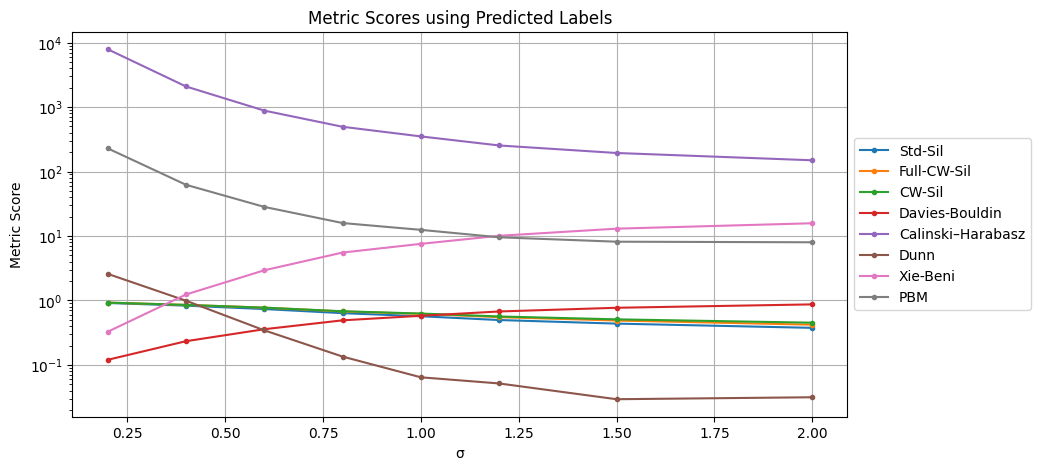

In [17]:
plt.figure(figsize=(10,5))
plt.plot(grouped_k3["std"], grouped_k3["Standard-Silhouette"], label="Std-Sil", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["Full-CW-Silhouette"], label="Full-CW-Sil", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["CW-Silhouette"], label="CW-Sil", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["DBI"], label="Davies-Bouldin", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["CHI"], label="Calinski–Harabasz", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["Dunn"], label="Dunn", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["XBI"], label="Xie-Beni", marker=".")
plt.plot(grouped_k3["std"], grouped_k3["PBM"], label="PBM", marker=".")

plt.axhline(0, linestyle="--")
plt.xlabel("σ")
plt.ylabel("Metric Score")
plt.yscale("log")
plt.title("Metric Scores using Predicted Labels")

# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.grid()

plt.show()

# K-Selection by Each Metric

In [18]:
columns = ["std", "run", "best_std_k", "best_fullcw_k", "best_cw_k", "best_dbi_k", "best_chi_k", "best_dun_k", "best_xbi_k", "best_pbm_k", "best_ari_k", "best_nmi_k"]
df = pd.DataFrame(results, columns=columns)
display(df)

,std,run,best_std_k,best_fullcw_k,best_cw_k,best_dbi_k,best_chi_k,best_dun_k,best_xbi_k,best_pbm_k,best_ari_k,best_nmi_k
0,0.2,0,3,3,3,3,3,3,3,3,3,3
1,0.2,1,3,3,3,3,3,3,3,3,3,3
2,0.2,2,3,3,3,3,3,3,3,3,3,3
3,0.2,3,3,3,3,3,3,3,3,3,3,3
4,0.2,4,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...
75,2.0,5,6,8,8,8,8,5,7,4,3,3
76,2.0,6,3,3,3,3,3,6,7,4,3,5
77,2.0,7,3,3,2,5,3,8,8,2,3,3
78,2.0,8,3,3,3,7,4,7,7,4,3,7


In [19]:
grouped = df.groupby("std").mean().reset_index()
grouped = grouped.drop("run", axis=1)
display(grouped)

,std,best_std_k,best_fullcw_k,best_cw_k,best_dbi_k,best_chi_k,best_dun_k,best_xbi_k,best_pbm_k,best_ari_k,best_nmi_k
0,0.2,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
1,0.4,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
2,0.6,3.0,3.0,3.0,3.0,3.0,2.9,3.0,3.0,3.0,3.0
3,0.8,3.0,3.0,3.0,3.0,3.0,2.6,3.0,3.2,3.0,3.0
4,1.0,3.0,3.0,3.0,3.0,3.0,4.2,4.0,3.0,3.0,3.0
5,1.2,3.0,3.0,3.0,3.0,3.0,5.6,7.3,3.8,3.0,3.0
6,1.5,3.0,3.0,3.0,4.1,3.0,6.7,7.8,4.5,3.0,3.3
7,2.0,3.8,4.0,3.9,6.2,4.3,6.1,7.5,4.1,3.0,3.9


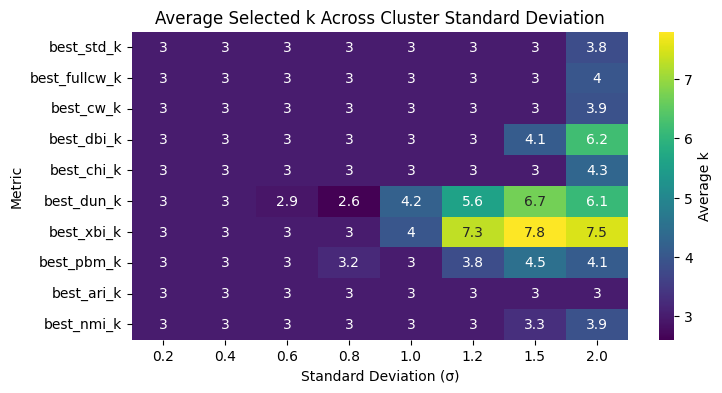

In [20]:
plt.figure(figsize=(8, 4))
sns.heatmap(
    grouped.set_index("std").T,
    annot=True,
    cmap="viridis",
    cbar_kws={"label": "Average k"},
)

plt.xlabel("Standard Deviation (σ)")
plt.ylabel("Metric")
plt.title("Average Selected k Across Cluster Standard Deviation")
plt.show()

# Spearman Correlation of Internal Validation Metrics with External Validation Metrics

In [21]:
columns_corr_ari = ["std", "run", "corr_std", "p_std", "corr_fullcw", "p_fullcw", "corr_cw", "p_cw", "corr_dbi", "p_dbi", "corr_chi", "p_chi", "corr_dun", "p_dun", "corr_xbi", "p_xbi", "corr_pbm", "p_pbm"]
df_corr_ari = pd.DataFrame(results_corr_ari, columns=columns_corr_ari)
display(df_corr_ari)

,std,run,corr_std,p_std,corr_fullcw,p_fullcw,corr_cw,p_cw,corr_dbi,p_dbi,corr_chi,p_chi,corr_dun,p_dun,corr_xbi,p_xbi,corr_pbm,p_pbm
0,0.2,0,0.714286,0.071344,0.714286,0.071344,0.714286,0.071344,0.678571,0.093750,0.892857,0.006807,0.306319,0.504027,-0.142857,0.759945,0.892857,0.006807
1,0.2,1,0.714286,0.071344,0.678571,0.093750,0.714286,0.071344,0.571429,0.180202,0.892857,0.006807,0.118217,0.800709,-0.142857,0.759945,0.892857,0.006807
2,0.2,2,0.714286,0.071344,0.821429,0.023449,0.821429,0.023449,0.678571,0.093750,0.892857,0.006807,0.642857,0.119392,-0.178571,0.701658,0.892857,0.006807
3,0.2,3,0.750000,0.052181,0.714286,0.071344,0.857143,0.013697,0.571429,0.180202,0.857143,0.013697,0.607143,0.148231,-0.142857,0.759945,0.892857,0.006807
4,0.2,4,0.678571,0.093750,0.821429,0.023449,0.821429,0.023449,0.571429,0.180202,0.892857,0.006807,0.214286,0.644512,-0.250000,0.588724,0.892857,0.006807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2.0,5,-0.214286,0.644512,-0.464286,0.293934,-0.428571,0.337368,-0.500000,0.253170,-0.428571,0.337368,0.392857,0.383317,-0.428571,0.337368,-0.535714,0.215217
76,2.0,6,0.964286,0.000454,0.821429,0.023449,0.750000,0.052181,0.464286,0.293934,0.857143,0.013697,0.321429,0.482072,-0.500000,0.253170,0.357143,0.431611
77,2.0,7,0.321429,0.482072,0.714286,0.071344,0.607143,0.148231,-0.214286,0.644512,0.428571,0.337368,-0.250000,0.588724,-0.607143,0.148231,0.535714,0.215217
78,2.0,8,0.821429,0.023449,0.750000,0.052181,0.750000,0.052181,0.571429,0.180202,0.607143,0.148231,0.000000,1.000000,-0.285714,0.534509,0.107143,0.819151


In [22]:
grouped_corr_ari = df_corr_ari.groupby("std").mean().reset_index()
grouped_corr_ari = grouped_corr_ari.drop("run", axis=1)
display(grouped_corr_ari)

,std,corr_std,p_std,corr_fullcw,p_fullcw,corr_cw,p_cw,corr_dbi,p_dbi,corr_chi,p_chi,corr_dun,p_dun,corr_xbi,p_xbi,corr_pbm,p_pbm
0,0.2,0.710714,0.074233,0.725000,0.068811,0.764286,0.050560,0.603571,0.154266,0.885714,0.008185,0.369126,0.417278,-0.182143,0.696786,0.892857,0.006807
1,0.4,0.714286,0.075209,0.725000,0.072569,0.728571,0.070329,0.507143,0.260453,0.878571,0.010439,0.231408,0.576999,-0.189286,0.685473,0.878571,0.010439
2,0.6,0.782143,0.041938,0.796429,0.037400,0.842857,0.027353,0.621429,0.154982,0.875000,0.011128,0.471152,0.339602,-0.114286,0.808665,0.882143,0.009750
3,0.8,0.814286,0.032702,0.821429,0.026504,0.832143,0.023488,0.596429,0.184017,0.775000,0.048920,0.427448,0.406747,-0.096429,0.826246,0.857143,0.028127
4,1.0,0.764286,0.056842,0.800000,0.040054,0.817857,0.036222,0.635714,0.175325,0.846429,0.021430,0.242857,0.323277,-0.053571,0.874486,0.867857,0.016016
5,1.2,0.792857,0.073330,0.807143,0.056023,0.821429,0.052481,0.507143,0.292198,0.782143,0.046704,-0.210238,0.495864,-0.367857,0.442396,0.685714,0.115997
6,1.5,0.717857,0.116191,0.767857,0.064233,0.771429,0.094934,0.146429,0.658029,0.614286,0.170175,-0.249386,0.300392,-0.542857,0.237574,0.603571,0.216421
7,2.0,0.464286,0.331804,0.457143,0.205680,0.507143,0.222088,-0.075000,0.407953,0.292857,0.340285,-0.003571,0.539456,-0.517857,0.270155,0.075000,0.571537


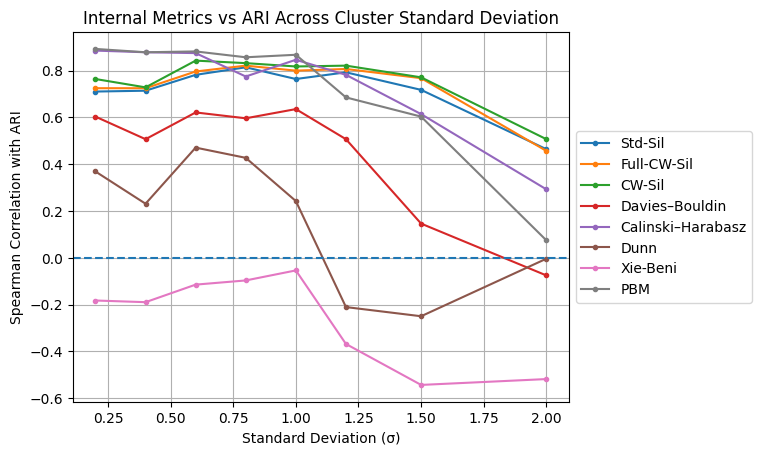

In [23]:
plt.figure()
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_std"], label="Std-Sil", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_fullcw"], label="Full-CW-Sil", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_cw"], label="CW-Sil", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_dbi"], label="Davies–Bouldin", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_chi"], label="Calinski–Harabasz", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_dun"], label="Dunn", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_xbi"], label="Xie-Beni", marker=".")
plt.plot(grouped_corr_ari["std"], grouped_corr_ari["corr_pbm"], label="PBM", marker=".")



plt.axhline(0, linestyle="--")
plt.xlabel("Standard Deviation (σ)")
plt.ylabel("Spearman Correlation with ARI")
plt.title("Internal Metrics vs ARI Across Cluster Standard Deviation")
plt.grid()

# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [24]:
columns_corr_nmi = ["std", "run", "corr_std", "p_std", "corr_fullcw", "p_fullcw", "corr_cw", "p_cw", "corr_dbi", "p_dbi", "corr_chi", "p_chi", "corr_dun", "p_dun", "corr_xbi", "p_xbi", "corr_pbm", "p_pbm"]
df_corr_nmi = pd.DataFrame(results_corr_nmi, columns=columns_corr_nmi)
display(df_corr_nmi)

,std,run,corr_std,p_std,corr_fullcw,p_fullcw,corr_cw,p_cw,corr_dbi,p_dbi,corr_chi,p_chi,corr_dun,p_dun,corr_xbi,p_xbi,corr_pbm,p_pbm
0,0.2,0,0.714286,0.071344,0.714286,0.071344,0.714286,0.071344,0.678571,0.093750,0.892857,0.006807,0.306319,0.504027,-0.142857,0.759945,0.892857,0.006807
1,0.2,1,0.714286,0.071344,0.678571,0.093750,0.714286,0.071344,0.571429,0.180202,0.892857,0.006807,0.118217,0.800709,-0.142857,0.759945,0.892857,0.006807
2,0.2,2,0.642857,0.119392,0.750000,0.052181,0.750000,0.052181,0.571429,0.180202,0.964286,0.000454,0.535714,0.215217,-0.107143,0.819151,0.964286,0.000454
3,0.2,3,0.607143,0.148231,0.642857,0.119392,0.714286,0.071344,0.428571,0.337368,0.892857,0.006807,0.500000,0.253170,-0.107143,0.819151,0.964286,0.000454
4,0.2,4,0.678571,0.093750,0.821429,0.023449,0.821429,0.023449,0.571429,0.180202,0.892857,0.006807,0.214286,0.644512,-0.250000,0.588724,0.892857,0.006807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2.0,5,0.571429,0.180202,0.285714,0.534509,-0.107143,0.819151,0.178571,0.701658,0.392857,0.383317,0.071429,0.879048,0.321429,0.482072,-0.357143,0.431611
76,2.0,6,0.821429,0.023449,0.535714,0.215217,0.321429,0.482072,0.321429,0.482072,0.892857,0.006807,0.607143,0.148231,0.000000,1.000000,0.642857,0.119392
77,2.0,7,0.071429,0.879048,0.214286,0.644512,0.000000,1.000000,0.321429,0.482072,0.500000,0.253170,0.035714,0.939408,0.000000,1.000000,-0.214286,0.644512
78,2.0,8,0.107143,0.819151,0.250000,0.588724,-0.071429,0.879048,0.464286,0.293934,0.214286,0.644512,0.321429,0.482072,0.785714,0.036238,0.071429,0.879048


In [25]:
grouped_corr_nmi = df_corr_nmi.groupby("std").mean().reset_index()
grouped_corr_nmi = grouped_corr_nmi.drop("run", axis=1)
display(grouped_corr_nmi)

,std,corr_std,p_std,corr_fullcw,p_fullcw,corr_cw,p_cw,corr_dbi,p_dbi,corr_chi,p_chi,corr_dun,p_dun,corr_xbi,p_xbi,corr_pbm,p_pbm
0,0.2,0.671429,0.102093,0.689286,0.090899,0.721429,0.069767,0.553571,0.202990,0.910714,0.005590,0.333347,0.436606,-0.153571,0.743945,0.921429,0.004266
1,0.4,0.689286,0.090884,0.703571,0.085063,0.707143,0.082822,0.475000,0.292970,0.896429,0.006861,0.220693,0.580885,-0.178571,0.702595,0.896429,0.006861
2,0.6,0.750000,0.062418,0.764286,0.057881,0.810714,0.047833,0.575000,0.199217,0.900000,0.006915,0.442484,0.362968,-0.089286,0.850136,0.907143,0.005537
3,0.8,0.739286,0.083603,0.750000,0.068928,0.767857,0.060588,0.517857,0.277334,0.800000,0.040127,0.348877,0.482983,-0.046429,0.873682,0.875000,0.016014
4,1.0,0.589286,0.196416,0.635714,0.143110,0.657143,0.132741,0.471429,0.333307,0.939286,0.003111,0.207143,0.452711,0.171429,0.707248,0.778571,0.063860
5,1.2,0.689286,0.130739,0.703571,0.113673,0.728571,0.089430,0.610714,0.200666,0.907143,0.010161,-0.070823,0.561609,-0.064286,0.845733,0.707143,0.099321
6,1.5,0.521429,0.285963,0.550000,0.253722,0.525000,0.284984,0.403571,0.394457,0.739286,0.094047,-0.029824,0.548995,-0.078571,0.809308,0.460714,0.330695
7,2.0,0.475000,0.370921,0.403571,0.382040,0.275000,0.509877,0.328571,0.484629,0.542857,0.263749,0.257143,0.428269,0.157143,0.705052,0.078571,0.606365


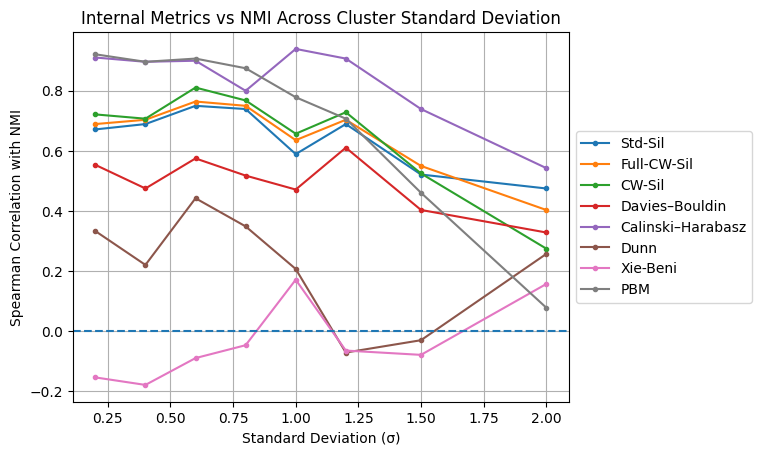

In [26]:
plt.figure()
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_std"], label="Std-Sil", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_fullcw"], label="Full-CW-Sil", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_cw"], label="CW-Sil", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_dbi"], label="Davies–Bouldin", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_chi"], label="Calinski–Harabasz", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_dun"], label="Dunn", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_xbi"], label="Xie-Beni", marker=".")
plt.plot(grouped_corr_nmi["std"], grouped_corr_nmi["corr_pbm"], label="PBM", marker=".")



plt.axhline(0, linestyle="--")
plt.xlabel("Standard Deviation (σ)")
plt.ylabel("Spearman Correlation with NMI")
plt.title("Internal Metrics vs NMI Across Cluster Standard Deviation")
plt.grid()

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


plt.show()